# 📧 KLASIFKASI EMAIL SPAM BAHASA INDONESIA MENGGUNAKAN ALGORITMA SPPORT VECTOR MACHINE

## Dataset Wanda:
- **email_spam_indo.csv** -

## Algoritma yang digunakan:
Support Vector Machine (SVM)

## Output:
- Model terbaik akan disimpan di folder `models/`

## 1. Import Data & Library

In [2]:
print("\nBismillah")


!pip install Sastrawi
!pip install wordcloud

import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings('ignore')


from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.svm import LinearSVC


from sklearn.model_selection import StratifiedKFold


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


import joblib

print("library sudah siap, lanjut proses...")



Bismillah
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.2 MB/s eta 0:00:00
library sudah siap, lanjut proses...


## 2. EDA (Exploratory Data Analysis)

Lihat Dataset

In [3]:
print("Mulai dataset...")

df = pd.read_csv('email_spam_indo.csv')

print("Total data:", len(df))
print(" Data sudah masuk")

print("\nTampilan Dataset:")
df.head()

Mulai dataset...
Total data: 1175
 Data sudah masuk

Tampilan Dataset:


,Kategori,Pesan,cleaning,case_folding,normalisasi,tokenisasi,stopword_removal,Stemming,final_text
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...,"['secara', 'alami', 'tidak', 'tertahankan', 'i...","['alami', 'tertahankan', 'identitas', 'perusah...","['alami', 'tahan', 'identitas', 'usaha', 'sang...",alami tahan identitas usaha sangat sulit ingat...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...,"['fanny', 'gunslinger', 'perdagangan', 'saham'...","['fanny', 'gunslinger', 'perdagangan', 'saham'...","['fanny', 'gunslinger', 'dagang', 'saham', 'me...",fanny gunslinger dagang saham merrill muzo buk...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,"['rumah', 'rumah', 'baru', 'yang', 'luar', 'bi...","['rumah', 'rumah', 'baru', 'luar', 'biasa', 'm...","['rumah', 'rumah', 'baru', 'luar', 'biasa', 'j...",rumah rumah baru luar biasa jadi mudah tunjuk ...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...,"['permintaan', 'khusus', 'pencetakan', 'warna'...","['permintaan', 'khusus', 'pencetakan', 'warna'...","['minta', 'khusus', 'cetak', 'warna', 'informa...",minta khusus cetak warna informasi tambah seka...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...,jangan punya uang dapatkan cd perangkat lunak ...,jangan punya uang dapatkan celana dalam perang...,"['jangan', 'punya', 'uang', 'dapatkan', 'celan...","['jangan', 'punya', 'uang', 'dapatkan', 'celan...","['jangan', 'punya', 'uang', 'dapat', 'celana',...",jangan punya uang dapat celana perangkat lunak...


Explore struktur kelas yaitu spam dan ham. Analisis Struktur Data

In [14]:
print("DATASET EMAIL SPAM INDONESIA")
print("-" * 40)

print("Ukuran data:", df.shape)
print("\nKolom yang ada:", df.columns.tolist())

print("\nTipe data:")
print(df.dtypes)

print("\nLabel awal:")
print(df['Kategori'].value_counts())

# UBAH LABEL: spam = 1, ham = 0
df['Kategori'] = df['Kategori'].map({'spam': 1, 'ham': 0})

print("\nLabel setelah encoding:")
print(df['Kategori'].value_counts())

DATASET EMAIL SPAM INDONESIA
----------------------------------------
Ukuran data: (2636, 2)

Kolom yang ada: ['Kategori', 'Pesan']

Tipe data:
Kategori    object
Pesan       object
dtype: object

Label awal:
Kategori
spam    1368
ham     1268
Name: count, dtype: int64

Label setelah encoding:
Kategori
1    1368
0    1268
Name: count, dtype: int64


## 3. Data Pra Pemrosesan


**1. Pengecekan Data Kosong (Handle missing Values)**

In [15]:
print("Cek missing values SEBELUM ditangani:\n")

print(df.isnull().sum())

print("\nPersentase missing values (%):")
print((df.isnull().sum() / len(df)) * 100)

Cek missing values SEBELUM ditangani:

Kategori    0
Pesan       0
dtype: int64

Persentase missing values (%):
Kategori    0.0
Pesan       0.0
dtype: float64


**2. CLEANING**

*   Menghapus URL
*   Menghapus alamat email
*   Menghapus tag HTML
*   Menghapus tanda baca
*   Menghapus angka
*   Menghapus spasi berlebih

In [16]:
import re
import string

def cleaning_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # Hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Hapus email
    text = re.sub(r'\S+@\S+', '', text)

    # Hapus HTML
    text = re.sub(r'<.*?>', '', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Hapus huruf berulang (coooool → cool)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text
    print(" Mulai cleaning...")

df['cleaning'] = df['Pesan'].apply(cleaning_text)
df = df[['Kategori', 'Pesan', 'cleaning']]
df.head(4)

,Kategori,Pesan,cleaning
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...


**3. Case Folding**

In [17]:
def case_folding(text):
    if isinstance(text, str):
        return text.lower()
    return ""
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(4)

,Kategori,Pesan,cleaning,case_folding
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...


In [8]:
def case_folding(text):
    if isinstance(text, str):
        return text.lower()
    return ""
df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(2638)

,Kategori,Pesan,cleaning,case_folding
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...,jangan punya uang dapatkan cd perangkat lunak ...
...,...,...,...,...
2631,0,Pengingat halo semuanya: Vince telah meminta s...,Pengingat halo semuanya Vince telah meminta sa...,pengingat halo semuanya vince telah meminta sa...
2632,0,Re: Argentina Power & Gas Market Modeling Oke ...,Re Argentina Power Gas Market Modeling Oke Jul...,re argentina power gas market modeling oke jul...
2633,0,"Re: Program Enron / Stanford Stinson, hebat! S...",Re Program Enron Stanford Stinson hebat Saya m...,re program enron stanford stinson hebat saya m...
2634,0,"Persetujuan untuk peninjau Roberts JR, Michael...",Persetujuan untuk peninjau Roberts JR Michael ...,persetujuan untuk peninjau roberts jr michael ...


**4. NORMALISASI**

In [18]:
import pandas as pd
import re

# LOAD KAMUS DARI GITHUB (slang -> formal)

url = "https://raw.githubusercontent.com/evrintobing17/NormalisasiKata/master/colloquial-indonesian-lexicon.csv"
normalization_data = pd.read_csv(url)
normalization_dict = dict(zip(normalization_data['slang'], normalization_data['formal']))

custom_dict = {
    # === Bahasa Gaul / Slang ===
    "bro": "saudara",
    "gan": "saudara",
    "sis": "saudara",
    "keren": "bagus",
    "kayak": "seperti",
    "nggak": "tidak",
    "gak": "tidak",
    "ga": "tidak",
    "g": "tidak",
    "cuma": "hanya",
    "dibilang": "dikatakan",
    "banget": "sangat",
    "bgt": "sangat",
    "cakep": "cantik",
    "gue": "saya",
    "gua": "saya",
    "gw": "saya",
    "lo": "kamu",
    "lu": "kamu",
    "doang": "saja",
    "bosen": "bosan",
    "dikit": "sedikit",
    "dikitdikit": "sedikit-sedikit",
    "kepo": "ingin tahu",

    # === Bahasa Tidak Baku ===
    "gmana": "bagaimana",
    "gmn": "bagaimana",
    "jg": "juga",
    "dpt": "dapat",
    "aja": "saja",
    "udah": "sudah",
    "udh": "sudah",
    "bikin": "membuat",
    "cepet": "cepat",
    "gimana": "bagaimana",
    "org": "orang",
    "tp": "tetapi",
    "tpi": "tetapi",
    "sdh": "sudah",
    "skrg": "sekarang",
    "skr": "sekarang",
    "blm": "belum",
    "sblm": "sebelum",
    "dgn": "dengan",
    "utk": "untuk",
    "pd": "pada",
    "tdk": "tidak",
    "brp": "berapa",
    "kpn": "kapan",
    "dr": "dari",
    "dri": "dari",
    "kpd": "kepada",
    "krn": "karena",
    "spt": "seperti",
    "bg": "begitu",
    "dll": "dan lain-lain",
    "dsb": "dan sebagainya",
    "klo": "kalau",
    "kalo": "kalau",
    "kl": "kalau",
    "pdhl": "padahal",
    "msh": "masih",
    "msk": "masuk",
    "byk": "banyak",
    "sdikit": "sedikit",
    "bbrp": "beberapa",
    "lgsg": "langsung",

    # === Kata kerja tidak baku ===
    "ngasih": "memberi",
    "ngambil": "mengambil",
    "ngirim": "mengirim",
    "ngerjain": "mengerjakan",
    "ngecek": "memeriksa",
    "nyoba": "mencoba",
    "nyari": "mencari",
    "nulis": "menulis",
    "dapet": "mendapat",
    "dapatin": "mendapatkan",

    # === Typo umum ===
    "bernn": "benar",
    "bener": "benar",
    "mendapat": "mendapatkan",
    "skarang": "sekarang",
    "trima": "terima",
    "trm": "terima",
    "trims": "terima kasih",
    "makasih": "terima kasih",

    # === Lainnya ===
    "ny": "nya",
    "moga": "semoga",
    "smoga": "semoga",
    "tak": "tidak",
    "tf": "transfer",
    "trf": "transfer",
    "apps": "aplikasi",
    "aplkasi": "aplikasi",
    "apkikasi": "aplikasi",
    "keluar": "keluar",
    "terus": "terus",
    "langsung": "langsung",
    "biasa": "biasa",

}



# GABUNGKAN KAMUS
normalization_dict.update(custom_dict)

# FUNGSI NORMALISASI
def normalize_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    words = text.split()
    normalized_words = [normalization_dict.get(word, word) for word in words]

    return " ".join(normalized_words)

print("Memulai normalisasi...")

# LANGSUNG PAKAI case_folding (TIDAK PERLU IF ELSE)
df['normalisasi'] = df['case_folding'].apply(normalize_text)

print("Normalisasi selesai!")

# URUTKAN KOLOM SESUAI YANG DIINGINKAN
df = df[['Kategori', 'Pesan', 'cleaning', 'case_folding', 'normalisasi']]

df.head()

Memulai normalisasi...
Normalisasi selesai!


,Kategori,Pesan,cleaning,case_folding,normalisasi
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...
4,1,"Jangan punya uang, dapatkan CD perangkat lunak...",Jangan punya uang dapatkan CD perangkat lunak ...,jangan punya uang dapatkan cd perangkat lunak ...,jangan punya uang dapatkan celana dalam perang...


**5. TOKENISASI**

In [19]:
print(" Proses Tokenizing...")

df['tokenisasi'] = df['normalisasi'].apply(lambda x: x.split())

df.head(4)

 Proses Tokenizing...


,Kategori,Pesan,cleaning,case_folding,normalisasi,tokenisasi
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...,"[secara, alami, tidak, tertahankan, identitas,..."
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah..."
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,"[rumah, rumah, baru, yang, luar, biasa, menjad..."
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...,"[permintaan, khusus, pencetakan, warna, inform..."


**6. Stopword removal**

In [20]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("Stopword Removal...")

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

def remove_stopwords(tokenisasi):
    return [word for word in tokenisasi if word not in stopwords]

# simpan hasil ke kolom baru
df['stopword_removal'] = df['tokenisasi'].apply(remove_stopwords)

df.head(4)

Stopword Removal...


,Kategori,Pesan,cleaning,case_folding,normalisasi,tokenisasi,stopword_removal
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...,"[secara, alami, tidak, tertahankan, identitas,...","[alami, tertahankan, identitas, perusahaan, sa..."
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril..."
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,"[rumah, rumah, baru, yang, luar, biasa, menjad...","[rumah, rumah, baru, luar, biasa, menjadi, mud..."
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...,"[permintaan, khusus, pencetakan, warna, inform...","[permintaan, khusus, pencetakan, warna, inform..."


**7. Stemming**

In [22]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print("\nStemming...")

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['Stemming'] = df['stopword_removal'].apply(stemming)

df.head(4)


Stemming...


,Kategori,Pesan,cleaning,case_folding,normalisasi,tokenisasi,stopword_removal,Stemming
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...,"[secara, alami, tidak, tertahankan, identitas,...","[alami, tertahankan, identitas, perusahaan, sa...","[alami, tahan, identitas, usaha, sangat, sulit..."
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril...","[fanny, gunslinger, dagang, saham, merrill, mu..."
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,"[rumah, rumah, baru, yang, luar, biasa, menjad...","[rumah, rumah, baru, luar, biasa, menjadi, mud...","[rumah, rumah, baru, luar, biasa, jadi, mudah,..."
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...,"[permintaan, khusus, pencetakan, warna, inform...","[permintaan, khusus, pencetakan, warna, inform...","[minta, khusus, cetak, warna, informasi, tamba..."


**8. REMOVE DUPLICATE / FINAL TEKS**

In [23]:
df['final_text'] = df['Stemming'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
df['final_text'] = df['final_text'].astype(str)
df = df[df['final_text'].str.strip() != ""]
df = df.drop_duplicates(subset=['final_text'])
df = df.reset_index(drop=True)
df.head(4)

,Kategori,Pesan,cleaning,case_folding,normalisasi,tokenisasi,stopword_removal,Stemming,final_text
0,1,Secara alami tak tertahankan identitas perusah...,Secara alami tak tertahankan identitas perusah...,secara alami tak tertahankan identitas perusah...,secara alami tidak tertahankan identitas perus...,"[secara, alami, tidak, tertahankan, identitas,...","[alami, tertahankan, identitas, perusahaan, sa...","[alami, tahan, identitas, usaha, sangat, sulit...",alami tahan identitas usaha sangat sulit ingat...
1,1,Fanny Gunslinger Perdagangan Saham adalah Merr...,Fanny Gunslinger Perdagangan Saham adalah Merr...,fanny gunslinger perdagangan saham adalah merr...,fanny gunslinger perdagangan saham adalah merr...,"[fanny, gunslinger, perdagangan, saham, adalah...","[fanny, gunslinger, perdagangan, saham, merril...","[fanny, gunslinger, dagang, saham, merrill, mu...",fanny gunslinger dagang saham merrill muzo buk...
2,1,Rumah -rumah baru yang luar biasa menjadi muda...,Rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,rumah rumah baru yang luar biasa menjadi mudah...,"[rumah, rumah, baru, yang, luar, biasa, menjad...","[rumah, rumah, baru, luar, biasa, menjadi, mud...","[rumah, rumah, baru, luar, biasa, jadi, mudah,...",rumah rumah baru luar biasa jadi mudah tunjuk ...
3,1,4 Permintaan Khusus Pencetakan Warna Informasi...,Permintaan Khusus Pencetakan Warna Informasi T...,permintaan khusus pencetakan warna informasi t...,permintaan khusus pencetakan warna informasi t...,"[permintaan, khusus, pencetakan, warna, inform...","[permintaan, khusus, pencetakan, warna, inform...","[minta, khusus, cetak, warna, informasi, tamba...",minta khusus cetak warna informasi tambah seka...


In [24]:
df.to_csv('email_spam_indo_prapemrosesan.csv', index=False)


# 4. Penyeimbangan Data 2500 (1250 Spam dan Ham) Balancing**

In [25]:
from sklearn.utils import resample

print("Proses Data Balancing...")
print("=" * 50)

# Pastikan label string
df['Kategori'] = df['Kategori'].astype(str)

df_spam = df[df['Kategori'] == '1']
df_ham = df[df['Kategori'] == '0']

print("Sebelum balancing:")
print(df['Kategori'].value_counts())

df_spam_bal = resample(df_spam, replace=False, n_samples=1250, random_state=42)
df_ham_bal = resample(df_ham, replace=False, n_samples=1250, random_state=42)

df_balanced = pd.concat([df_spam_bal, df_ham_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSetelah balancing:")
print("Total data:", df_balanced.shape)
print(df_balanced['Kategori'].value_counts())

Proses Data Balancing...
Sebelum balancing:
Kategori
1    1367
0    1250
Name: count, dtype: int64

Setelah balancing:
Total data: (2500, 9)
Kategori
0    1250
1    1250
Name: count, dtype: int64


Grafik keseimbangan

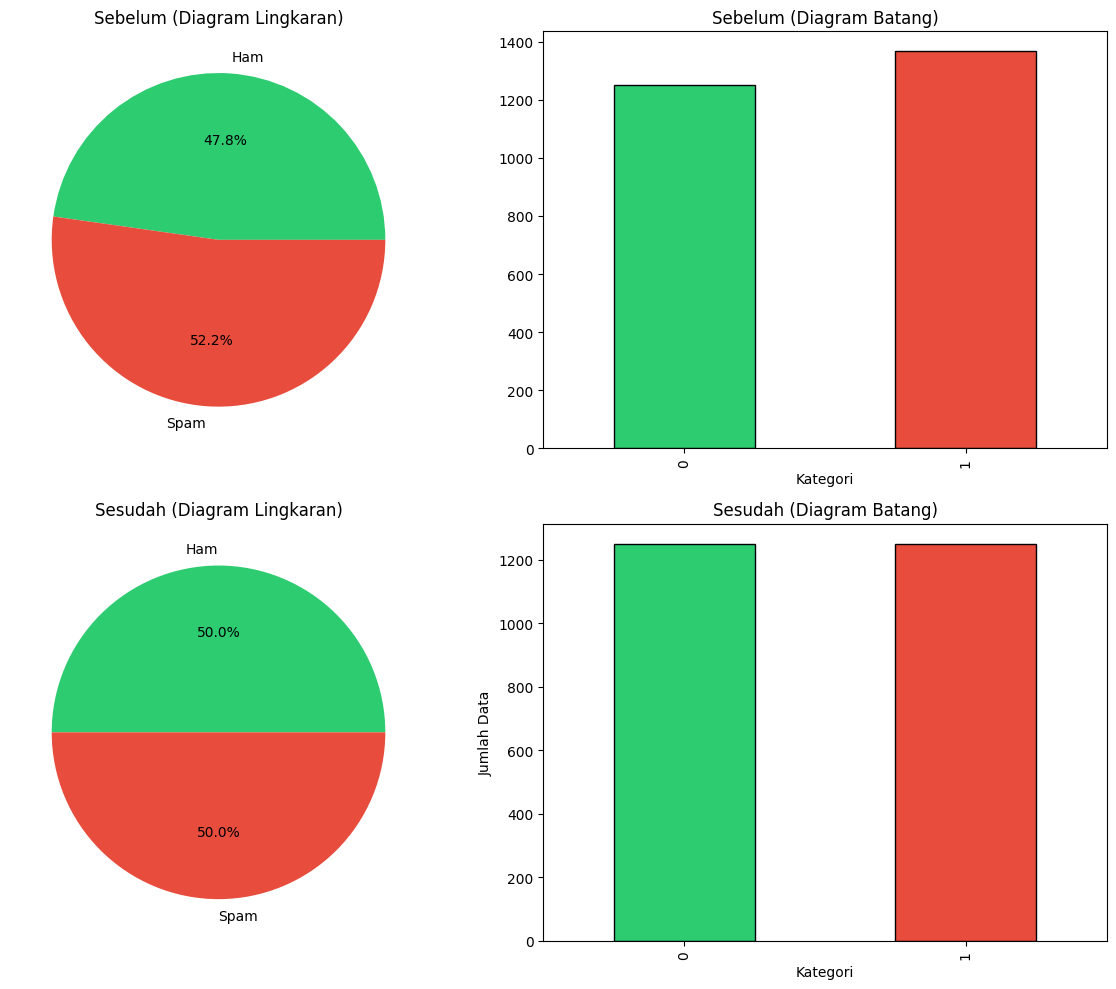

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

colors = ['#2ecc71', '#e74c3c']
labels = ['Ham', 'Spam']

# SEBELUM
sizes_before = df['Kategori'].value_counts().sort_index()

axes[0,0].pie(sizes_before, labels=labels, colors=colors, autopct='%1.1f%%')
axes[0,0].set_title('Sebelum (Diagram Lingkaran)')

df['Kategori'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,1], color=colors, edgecolor='black'
)
axes[0,1].set_title('Sebelum (Diagram Batang)')

plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
#SESUDAH
sizes_after = df_balanced['Kategori'].value_counts().sort_index()

axes[1,0].pie(sizes_after, labels=labels, colors=colors, autopct='%1.1f%%')
axes[1,0].set_title('Sesudah (Diagram Lingkaran)')

df_balanced['Kategori'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color=colors, edgecolor='black'
)
axes[1,1].set_title('Sesudah (Diagram Batang)')

plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

## 5. Text Vectorization (TF-IDF)

TF-IDF (Term Frequency-Inverse Document Frequency) akan mengubah teks menjadi representasi numerik yang dapat diproses oleh model ML.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

print("Membuat TF-IDF Vectorizer...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 2),
    lowercase=True
)

# FIT TF-IDF
X = tfidf_vectorizer.fit_transform(df_balanced['normalisasi'])

# LABEL (PASTIKAN SESUAI DATA KAMU)
y = df_balanced['Kategori'].astype(int)

print("\n TF-IDF selesai!")
print("Shape:", X.shape)

Membuat TF-IDF Vectorizer...

 TF-IDF selesai!
Shape: (2500, 10000)


In [28]:
# Ambil nama fitur (kata)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Ubah ke DataFrame
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)

tfidf_df.head()

,aa,abaikan,abstrak,ac,acadia,acara,acara ini,acara yang,acrobat,acrobat profesiai,...,young,young nya,your,ze,zhang,zimbabwe,zimin,zimin kamu,zip,zona
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Pengujian Model (K-Fold Cross Validation)

Manual split

*   Manual split
*   Validasi proporsi



In [29]:
from sklearn.model_selection import StratifiedKFold
import pandas as pd

print(" Pembagian data 5-Fold...")
print("=" * 50)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"\n Fold {i+1}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    print(f"Training: {X_train.shape[0]} | Testing: {X_test.shape[0]}")
    print("Distribusi training:")
    print(pd.Series(y_train).value_counts())
    print("Distribusi testing:")
    print(pd.Series(y_test).value_counts())

 Pembagian data 5-Fold...

 Fold 1
Training: 2000 | Testing: 500
Distribusi training:
Kategori
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
Kategori
0    250
1    250
Name: count, dtype: int64

 Fold 2
Training: 2000 | Testing: 500
Distribusi training:
Kategori
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
Kategori
1    250
0    250
Name: count, dtype: int64

 Fold 3
Training: 2000 | Testing: 500
Distribusi training:
Kategori
1    1000
0    1000
Name: count, dtype: int64
Distribusi testing:
Kategori
0    250
1    250
Name: count, dtype: int64

 Fold 4
Training: 2000 | Testing: 500
Distribusi training:
Kategori
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
Kategori
0    250
1    250
Name: count, dtype: int64

 Fold 5
Training: 2000 | Testing: 500
Distribusi training:
Kategori
0    1000
1    1000
Name: count, dtype: int64
Distribusi testing:
Kategori
1    250
0    250
Name: count, dtype: int64


In [30]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import numpy as np

print("\n Evaluasi 5-Fold Cross Validation dengan SVM...")
print("=" * 50)

model = LinearSVC()

# akurasi tiap fold
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("\n Hasil akurasi tiap fold:")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\n Rata-rata akurasi: {np.mean(cv_scores):.4f}")


 Evaluasi 5-Fold Cross Validation dengan SVM...

 Hasil akurasi tiap fold:
Fold 1: 0.9960
Fold 2: 0.9860
Fold 3: 0.9880
Fold 4: 0.9860
Fold 5: 0.9900

 Rata-rata akurasi: 0.9892


Klasifikasi

In [31]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(model, X, y, cv=kf)

print("\n Classification Report:")
print(classification_report(y, y_pred))


 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1250
           1       0.99      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



## 7. Model Evaluation

In [32]:
import pandas as pd
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import LinearSVC

print("HASIL MODEL SVM (LinearSVC)")
print("=" * 60)

# Model
model = LinearSVC()

# Prediksi dengan cross validation
y_pred = cross_val_predict(model, X, y, cv=5)

# Hitung semua metrik dari hasil yang sama
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, pos_label=1)
recall = recall_score(y, y_pred, pos_label=1)
f1 = f1_score(y, y_pred, pos_label=1)

# Tampilkan dalam tabel
svm_result = pd.DataFrame({
    'Model': ['SVM (LinearSVC)'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1-Score': [f1]
})

display(svm_result.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

print("\nClassification Report:")
print(classification_report(y, y_pred))

HASIL MODEL SVM (LinearSVC)


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (LinearSVC),0.9880,0.9841,0.9920,0.9880



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1250
           1       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



evaluasi

📊 Visualisasi Hasil Model SVM


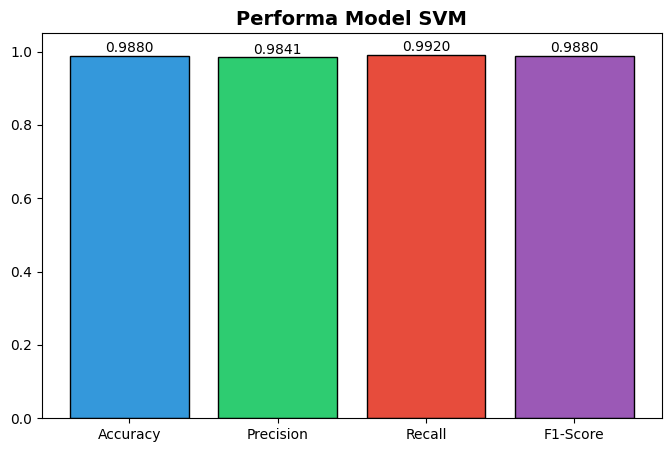

In [33]:
import matplotlib.pyplot as plt

print("📊 Visualisasi Hasil Model SVM")

# Ambil nilai dari hasil SVM
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [
    svm_result['Accuracy'][0],
    svm_result['Precision'][0],
    svm_result['Recall'][0],
    svm_result['F1-Score'][0]
]

# Warna (biru, hijau, merah, ungu)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=colors, edgecolor='black')

# Judul
plt.title('Performa Model SVM', fontsize=14, fontweight='bold')
plt.ylim(0, 1.05)

# Label nilai di atas bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.4f}', ha='center')

plt.show()

CONFUSION MATRIX PER FOLD (SVM LinearSVC)


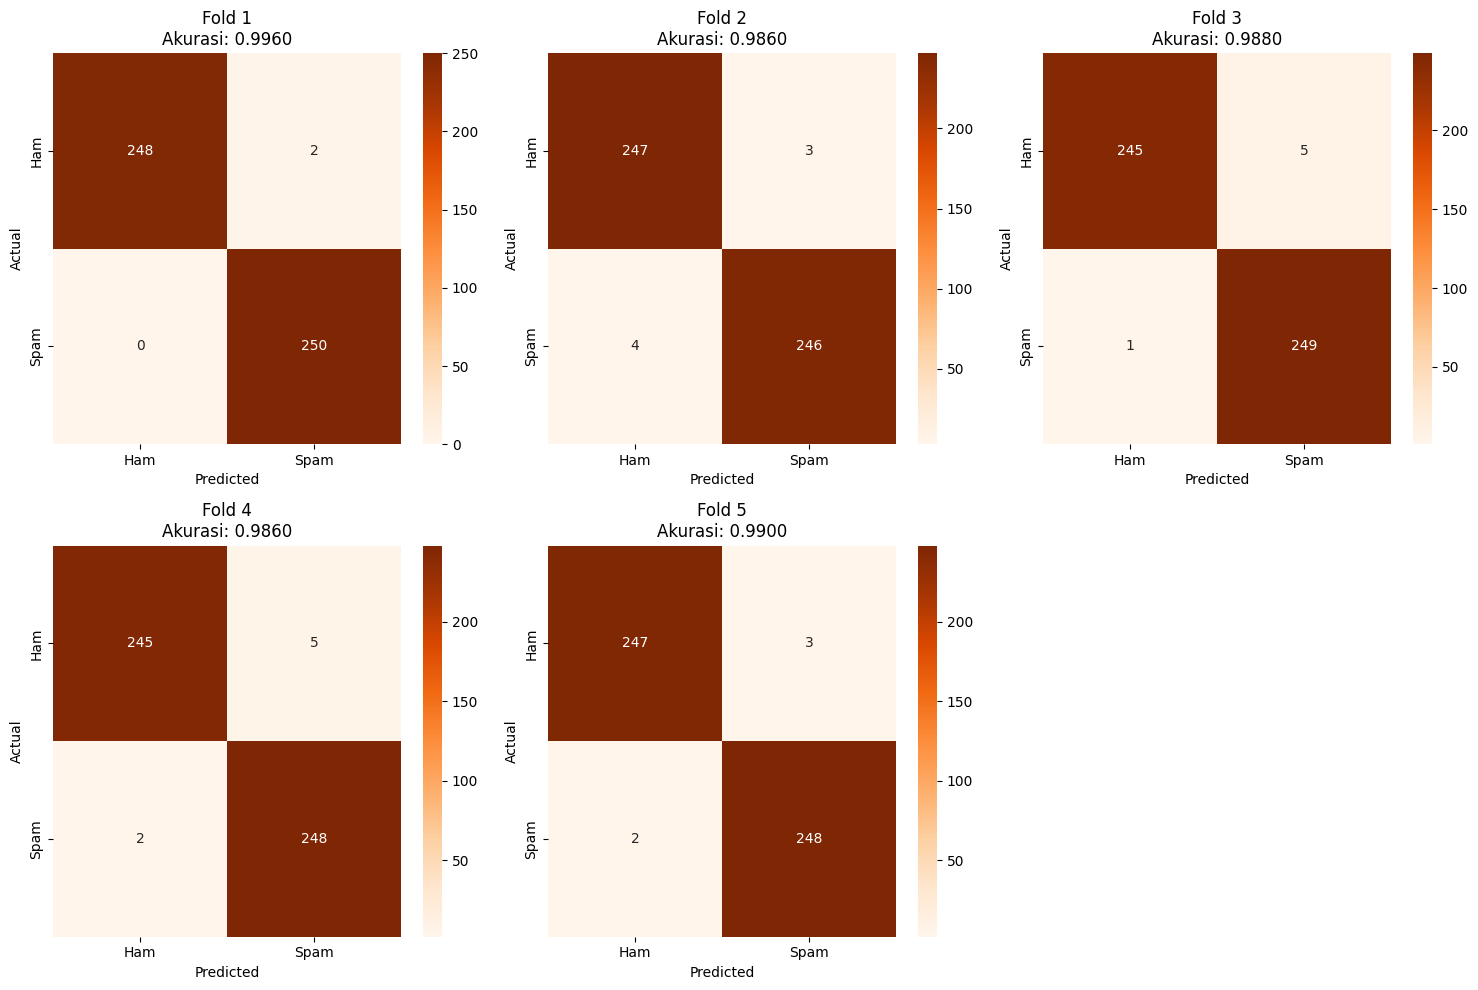


Akurasi tiap fold:
Fold 1: 0.9960
Fold 2: 0.9860
Fold 3: 0.9880
Fold 4: 0.9860
Fold 5: 0.9900

Rata-rata akurasi: 0.9892


In [42]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("CONFUSION MATRIX PER FOLD (SVM LinearSVC)")
print("=" * 60)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LinearSVC()

fold = 1
accuracies = []

plt.figure(figsize=(15,10))

for train_index, test_index in kf.split(X, y):

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Prediksi
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Akurasi
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    # Plot
    plt.subplot(2, 3, fold)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )

    plt.title(f'Fold {fold}\nAkurasi: {acc:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    fold += 1

plt.tight_layout()
plt.show()


In [35]:
from sklearn.metrics import classification_report

print("📋 Klasifikasi - SVM (LinearSVC)")
print("=" * 60)

print(classification_report(
    y, y_pred,
    target_names=['Ham (0)', 'Spam (1)']
))

📋 Klasifikasi - SVM (LinearSVC)
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.99      1250
    Spam (1)       0.98      0.99      0.99      1250

    accuracy                           0.99      2500
   macro avg       0.99      0.99      0.99      2500
weighted avg       0.99      0.99      0.99      2500



## 8. Simpan Model yang Telah Dilatih

Simpan model terbaik beserta vectorizer ke folder `models/` dengan format yang rapi dan timestamp.

In [37]:
import os
import joblib
import json
from datetime import datetime
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

print("💾 Menyimpan Model S...")

MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)


timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')


model_name = "SVM (LinearSVC)"
svm_model = model


model_filename = f'{MODEL_DIR}/svm_model_{timestamp}.joblib'
joblib.dump(svm_model, model_filename)


vectorizer_filename = f'{MODEL_DIR}/tfidf_vectorizer_{timestamp}.joblib'
joblib.dump(tfidf_vectorizer, vectorizer_filename)


# Use y_pred (which is already calculated in a previous cell) for metrics
model_metadata = {
    'model_name': model_name,
    'timestamp': timestamp,
    'metrics': {
        'accuracy': float(np.mean(cv_scores)),
        'precision': float(precision_score(y, y_pred, pos_label=1)),
        'recall': float(recall_score(y, y_pred, pos_label=1)),
        'f1_score': float(f1_score(y, y_pred, pos_label=1))
    },
    'data_info': {
        'total_data': len(df),
        'num_features': X.shape[1]
    }
}


metadata_filename = f'{MODEL_DIR}/model_metadata_{timestamp}.json'
with open(metadata_filename, 'w') as f:
    json.dump(model_metadata, f, indent=4)

print(f"\n✅ Metadata disimpan: {metadata_filename}")

print(f"\n📂 Isi folder '{MODEL_DIR}':")
for file in os.listdir(MODEL_DIR):
    file_path = os.path.join(MODEL_DIR, file)
    size_kb = os.path.getsize(file_path) / 1024
    print(f"   📄 {file} ({size_kb:.2f} KB)")

💾 Menyimpan Model S...

✅ Metadata disimpan: models/model_metadata_20260416_032745.json

📂 Isi folder 'models':
   📄 model_metadata_20260416_032745.json (0.31 KB)
   📄 svm_model_20260416_032642.joblib (0.27 KB)
   📄 tfidf_vectorizer_20260416_032745.joblib (392.64 KB)
   📄 tfidf_vectorizer_20260416_032642.joblib (392.64 KB)
   📄 svm_model_20260416_032745.joblib (0.27 KB)


## 9. Load and Test Saved Model

Load model yang sudah disimpan dan test dengan contoh email baru.

In [38]:
# Load model dan vectorizer yang tersimpan
print("📥 Loading saved model and vectorizer...")

loaded_model = joblib.load(model_filename)
loaded_vectorizer = joblib.load(vectorizer_filename)

print(f"✅ Model loaded: {model_filename}")
print(f"✅ Vectorizer loaded: {vectorizer_filename}")

📥 Loading saved model and vectorizer...
✅ Model loaded: models/svm_model_20260416_032745.joblib
✅ Vectorizer loaded: models/tfidf_vectorizer_20260416_032745.joblib


In [39]:

def predict_email(email_text, model=None, vectorizer=None):
    """
    Memprediksi apakah sebuah email adalah spam atau bukan.

    Parameters:
    -----------
    email_text : str
        Teks email yang akan diprediksi
    model : sklearn model
        Model yang sudah di-train (default: loaded_model)
    vectorizer : TfidfVectorizer
        Vectorizer yang sudah di-fit (default: loaded_vectorizer)

    Returns:
    --------
    dict : Dictionary berisi hasil prediksi dan confidence
    """
    if model is None:
        model = loaded_model
    if vectorizer is None:
        vectorizer = loaded_vectorizer


    cleaned_text = clean_text(email_text)


    text_vectorized = vectorizer.transform([cleaned_text])


    prediction = model.predict(text_vectorized)[0]


    try:

        proba = model.predict_proba(text_vectorized)[0]
        confidence = max(proba) * 100
    except AttributeError:
        confidence = None

    result = {
        'text_preview': email_text[:100] + '...' if len(email_text) > 100 else email_text,
        'prediction': 'SPAM 🚫' if prediction == 'spam' else 'HAM ✅',
        'label': 1 if prediction == 'spam' else 0,
        'confidence': f'{confidence:.2f}%' if confidence else 'N/A'
    }

    return result

print("✅ Fungsi predict_email() siap digunakan!")

✅ Fungsi predict_email() siap digunakan!


## 10. Ringkasan & Kesimpulan

In [40]:

print("📊 RINGKASAN HASIL KLASIFIKASI EMAIL SPAM")


print(f"""
📌 Informasi Dataset:
   • Total email yang diproses: {len(df)}
   • Data training: {X_train.shape[0]}
   • Data testing: {X_test.shape[0]}
   • Jumlah fitur (TF-IDF): {X.shape[1]}

🏆 Model yang Digunakan: SVM (LinearSVC)
   • Akurasi: {accuracy:.4f} ({accuracy*100:.2f}%)
   • Precision: {precision:.4f}
   • Recall: {recall:.4f}
   • F1-Score: {f1:.4f}
   • Nilai Cross-Validation: {np.mean(cv_scores):.4f}

📁 File yang Disimpan (folder 'models/'):
   • Model: {model_filename}
   • Vectorizer: {vectorizer_filename}
   • Metadata: {metadata_filename}

🚀 Contoh Penggunaan:

   model = joblib.load('{model_filename}')
   vectorizer = joblib.load('{vectorizer_filename}')


   text = "Selamat! Anda mendapatkan hadiah jutaan rupiah!"
   text_vec = vectorizer.transform([text])
   hasil = model.predict(text_vec)
   print("Hasil Prediksi:", "Spam" if hasil[0]==1 else "Ham")
""")


print("✅ Proses klasifikasi selesai!")


📊 RINGKASAN HASIL KLASIFIKASI EMAIL SPAM

📌 Informasi Dataset:
   • Total email yang diproses: 2617
   • Data training: 2000
   • Data testing: 500
   • Jumlah fitur (TF-IDF): 10000

🏆 Model yang Digunakan: SVM (LinearSVC)
   • Akurasi: 0.9880 (98.80%)
   • Precision: 0.9841
   • Recall: 0.9920
   • F1-Score: 0.9880
   • Nilai Cross-Validation: 0.9892

📁 File yang Disimpan (folder 'models/'):
   • Model: models/svm_model_20260416_032745.joblib
   • Vectorizer: models/tfidf_vectorizer_20260416_032745.joblib
   • Metadata: models/model_metadata_20260416_032745.json

🚀 Contoh Penggunaan:

   model = joblib.load('models/svm_model_20260416_032745.joblib')
   vectorizer = joblib.load('models/tfidf_vectorizer_20260416_032745.joblib')


   text = "Selamat! Anda mendapatkan hadiah jutaan rupiah!"
   text_vec = vectorizer.transform([text])
   hasil = model.predict(text_vec)
   print("Hasil Prediksi:", "Spam" if hasil[0]==1 else "Ham")

✅ Proses klasifikasi selesai!
